### Import Libraries

In [99]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
from scipy.stats import median_abs_deviation
from tabulate import tabulate
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold

### Load the Datasets

In [101]:
df_coffee = pd.read_csv("final_coffeeshops_dataset_cleaned (1).csv")
df_restaurant = pd.read_csv("final_restaurants_dataset_cleaned (1).csv")

print("--- Coffeeshops info: ---")
df_coffee.info()
print()
print("--- Resturants info: ---")
df_restaurant.info()

--- Coffeeshops info: ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 689 entries, 0 to 688
Data columns (total 39 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Business ID                               689 non-null    object 
 1   Name                                      689 non-null    object 
 2   Latitude                                  689 non-null    float64
 3   Longitude                                 689 non-null    float64
 4   Category                                  689 non-null    object 
 5   Rating                                    689 non-null    object 
 6   Popularity                                689 non-null    float64
 7   Google Place ID                           688 non-null    object 
 8   Business Status                           689 non-null    object 
 9   Distance (m)                              689 non-null    float64
 10  Cluster     

In [102]:
pd.set_option('display.max_columns', None)  # Show all columns

### Combine the Datasets

In [104]:
combined_df = pd.concat([df_coffee, df_restaurant], ignore_index=True)
combined_df["generalCategory"] = combined_df["generalCategory"].map({"coffee shop": 0, "restaurant": 1})
combined_df.info()
# Ensure that the 'Number of Reviewers' column is numeric and handle errors as NaN
combined_df['Number of Reviewers'] = pd.to_numeric(combined_df['Number of Reviewers'], errors='coerce')
combined_df[combined_df['Number of Reviewers'] > 10000]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1910 entries, 0 to 1909
Data columns (total 39 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Business ID                               1910 non-null   object 
 1   Name                                      1910 non-null   object 
 2   Latitude                                  1910 non-null   float64
 3   Longitude                                 1910 non-null   float64
 4   Category                                  1910 non-null   object 
 5   Rating                                    1910 non-null   object 
 6   Popularity                                1910 non-null   float64
 7   Google Place ID                           1909 non-null   object 
 8   Business Status                           1910 non-null   object 
 9   Distance (m)                              1910 non-null   float64
 10  Cluster                             

,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m),Cluster,generalCategory,Religious Institutions,Coffee Shops,Food & Dining,Restaurants,Home & Construction Services,Entertainment & Recreation,Retail & Shopping,Finance & Services,Education,Health,Public & Government Services,Hotels & Hospitality,Transportation & Travel,Beauty & Wellness,POI Density,Avg Rating - Business Type,Avg Rating - Food & Dining,Competition - Business Type/Area,Competition - Food & Dining/Area,Competition - Business Type/POI Density,Competition - Food & Dining/POI Density,Competition - Business Type/related POIs,Competition - Food & Dining/related POIs,Population Within 1km,Business Name,Google Rating,Number of Reviewers
26,5ff89cd2a6930e53ea957cfd,حصير الراشد,26.290708,50.180910,Coffee Shop,No rating,0.691850,ChIJRaJ9U9jnST4RAuAzsHZ26kk,OPERATIONAL,37.028405,NaN,0,0,1,8,7,0,0,22,0,1,1,0,27,0,0,58,4.000000,3.987500,0.318309,2.546473,0.017241,0.137931,0.017544,0.140351,32835,Al Rashid Mall,4.3,50834.0
390,5190fe20498e89cb8f086f36,chocolate cottage - othaim mall,26.400128,50.116904,Coffee Shop,No rating,0.892528,ChIJIfIATEv7ST4RMWQj-wL0NUE,OPERATIONAL,38.605192,NaN,0,0,4,11,8,0,0,36,2,4,1,1,0,0,0,59,3.800000,3.809091,1.273237,3.501401,0.067797,0.186441,0.085106,0.234043,13235,Al Othaim Mall,4.3,28815.0
696,561e181f498e3dede4fa6761,Blue Garden (بلو جاردن),26.255244,50.220898,Lebanese Restaurant,8.1,0.982453,ChIJRbM8f7_DST4RRf5n_pah-uU,OPERATIONAL,19.120883,NaN,1,0,2,9,8,0,3,3,2,0,0,0,0,3,0,57,4.150000,4.133333,2.546473,2.864782,0.140351,0.157895,0.533333,0.600000,8319,Blue Garden Restaurant Khobar,4.1,10964.0
842,5be97374ecb3ed00323d59c0,Fatté w Snobar (فتّة و صنوبر),26.304688,50.180190,Middle Eastern Restaurant,7.4,0.966533,ChIJcc6VkPvnST4RG-LrpYt8tWM,OPERATIONAL,21.607708,NaN,1,1,4,4,0,0,0,12,4,1,2,1,8,1,2,58,NaN,4.225000,0.000000,1.273237,0.000000,0.068966,0.000000,0.166667,22431,Fatte w Snobar,4.2,15287.0
1166,5da588d9e262fb00078de77c,ALBAIK (البيك),26.395639,50.041035,Fast Food Restaurant,9.1,0.998105,ChIJ36NJ48X9ST4RELsjHaBE7X8,OPERATIONAL,7.603094,NaN,1,0,2,17,14,0,0,18,5,0,2,0,0,1,0,58,3.978571,3.994118,4.456328,5.411255,0.241379,0.293103,0.400000,0.485714,24851,AlBaik,4.0,10741.0
1211,59134c9d6a8d866f90550b80,Al Romansiah Restaurants (مطاعم الرومانسية),26.405712,50.061759,Middle Eastern Restaurant,8.5,0.996884,ChIJZ40VJ-L8ST4R48LpXZGuH2c,OPERATIONAL,24.377082,NaN,1,0,1,11,10,0,0,15,7,0,5,0,1,2,0,58,3.790000,3.818182,3.183091,3.501401,0.172414,0.189655,0.370370,0.407407,18740,AlRomansiah Restaurant,4.1,16765.0
1333,5d9b02abd53c640008fac487,Al Baik (البيك),26.412991,50.110614,Fast Food Restaurant,8.9,0.996811,ChIJRTMTXs77ST4RJpIoNfdTBiM,OPERATIONAL,14.019940,NaN,1,0,3,13,10,0,0,13,2,4,8,3,0,0,0,59,3.940000,3.938462,3.183091,4.138019,0.169492,0.220339,0.384615,0.500000,26051,AlBaik,4.1,12938.0
1460,562096a3498efb1e8c4e54bd,سد مأرب | مأكولات يمنية,26.441470,50.073862,Halal Restaurant,8.1,0.988550,ChIJF58RzEb8ST4RuSU6DH9uhHs,OPERATIONAL,105.517584,NaN,1,0,0,5,5,0,0,18,3,1,2,1,2,7,1,59,3.980000,3.980000,1.591546,1.591546,0.084746,0.084746,0.200000,0.200000,55996,Sadd Ma'arib,4.4,18196.0
1485,5fbbcd98677695777e8f46c5,البيك,26.457044,50.108642,Fast Food Restaurant,8.8,0.993488,ChIJNTuNUAT7ST4RhPx4ppwn0SI,OPERATIONAL,11.289787,NaN,1,0,1,9,8,0,0,19,3,0,1,1,3,2,0,58,3.987500,4.000000,2.546473,2.864782,0.137931,0.155172,0.258065,0.290323,22466,AlBaik,4.1,10419.0
1650,53c48537498e9d813ebf0a9d,Heritage Village (القرية الشعبية),26.491727,50.120862,Middle Eastern Restaurant,7.6,0.999038,ChIJ5XedP5X7ST4Ruh7LAYx2BSw,OPERATIONAL,39.862332,NaN,1,4,3,9,6,0,8,5,1,1,1,1,0,2,4,57,4.233333,4.262500,1.909855,2.864782,0.105263,0.157895,0.272727,0.409091,4099,Heritage Village,4.2,12160.0


### Load the Datasets

In [106]:
combined_df = pd.read_csv('C:/Users/ranat/Desktop/hala (1)/combined_df.csv')
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1863 entries, 0 to 1862
Data columns (total 39 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Business ID                               1863 non-null   object 
 1   Name                                      1863 non-null   object 
 2   Latitude                                  1863 non-null   float64
 3   Longitude                                 1863 non-null   float64
 4   Category                                  1863 non-null   object 
 5   Rating                                    1863 non-null   object 
 6   Popularity                                1863 non-null   float64
 7   Google Place ID                           1863 non-null   object 
 8   Business Status                           1863 non-null   object 
 9   Distance (m)                              1863 non-null   float64
 10  Cluster                             

## Data Pre-processing

### Drop Irrelevent columns

In [109]:
# Drop irrelevant columns
drop_columns = ['Business ID', 'Latitude'	, 'Longitude', 'Name', 'Category', 'Rating', 'Google Place ID', 'Business Status',
                'Cluster', 'Distance (m)', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 'Competition - Food & Dining/Area',
                'Competition - Business Type/POI Density', 'Competition - Food & Dining/POI Densit', 'Competition - Business Type/related POIs'
               , 'Competition - Food & Dining/POI Density', 'Popularity', 'Google Rating', 'Business Name']

combined_df.drop(columns=drop_columns, inplace=True, errors='ignore')


In [110]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1863 entries, 0 to 1862
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   generalCategory                           1863 non-null   int64  
 1   Religious Institutions                    1863 non-null   int64  
 2   Coffee Shops                              1863 non-null   int64  
 3   Food & Dining                             1863 non-null   int64  
 4   Restaurants                               1863 non-null   int64  
 5   Home & Construction Services              1863 non-null   int64  
 6   Entertainment & Recreation                1863 non-null   int64  
 7   Retail & Shopping                         1863 non-null   int64  
 8   Finance & Services                        1863 non-null   int64  
 9   Education                                 1863 non-null   int64  
 10  Health                              

### Drop Rows with missing #of Reviewrs

In [112]:
# Ensure that the 'Number of Reviewers' column is numeric and handle errors as NaN
combined_df['Number of Reviewers'] = pd.to_numeric(combined_df['Number of Reviewers'], errors='coerce')

# Drop rows where 'Number of Reviewers' is NaN (if you want to ignore them in analysis)
combined_df = combined_df.dropna(subset=['Number of Reviewers'])

In [113]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1861 entries, 0 to 1862
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   generalCategory                           1861 non-null   int64  
 1   Religious Institutions                    1861 non-null   int64  
 2   Coffee Shops                              1861 non-null   int64  
 3   Food & Dining                             1861 non-null   int64  
 4   Restaurants                               1861 non-null   int64  
 5   Home & Construction Services              1861 non-null   int64  
 6   Entertainment & Recreation                1861 non-null   int64  
 7   Retail & Shopping                         1861 non-null   int64  
 8   Finance & Services                        1861 non-null   int64  
 9   Education                                 1861 non-null   int64  
 10  Health                                   

### Find Null values

In [115]:
print(combined_df.isnull().sum())

generalCategory                              0
Religious Institutions                       0
Coffee Shops                                 0
Food & Dining                                0
Restaurants                                  0
Home & Construction Services                 0
Entertainment & Recreation                   0
Retail & Shopping                            0
Finance & Services                           0
Education                                    0
Health                                       0
Public & Government Services                 0
Hotels & Hospitality                         0
Transportation & Travel                      0
Beauty & Wellness                            0
POI Density                                  0
Avg Rating - Food & Dining                  15
Competition - Food & Dining/related POIs     0
Population Within 1km                        0
Number of Reviewers                          0
dtype: int64


### Fill Missing Values with median

In [117]:
combined_df["Avg Rating - Food & Dining"] = combined_df["Avg Rating - Food & Dining"].fillna(combined_df["Avg Rating - Food & Dining"].median())
print(combined_df.isnull().sum())

generalCategory                             0
Religious Institutions                      0
Coffee Shops                                0
Food & Dining                               0
Restaurants                                 0
Home & Construction Services                0
Entertainment & Recreation                  0
Retail & Shopping                           0
Finance & Services                          0
Education                                   0
Health                                      0
Public & Government Services                0
Hotels & Hospitality                        0
Transportation & Travel                     0
Beauty & Wellness                           0
POI Density                                 0
Avg Rating - Food & Dining                  0
Competition - Food & Dining/related POIs    0
Population Within 1km                       0
Number of Reviewers                         0
dtype: int64


### Helper Functions (Highly Correlated Features, Outliers)

In [119]:
# Helper Functions to remove outliers and highly correlated features

def remove_outliers(X, y):
    """Remove outliers using IQR."""
    Q1 = np.percentile(y, 25)
    Q3 = np.percentile(y, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (y >= lower_bound) & (y <= upper_bound)
    return X[mask], y[mask]

    
# Remove Highly Correlated Features (Modified)
removed_corr_features = []  # List to store removed features

def remove_highly_correlated_features(X, threshold=0.9):
    """Removes highly correlated features from X."""
    corr_matrix = X.corr().abs()  # Compute absolute correlation matrix
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # Upper triangle

    # Find columns to drop
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    return X.drop(columns=to_drop, errors='ignore'), to_drop  # Drop and return removed features

### Visualization of Data Distribution

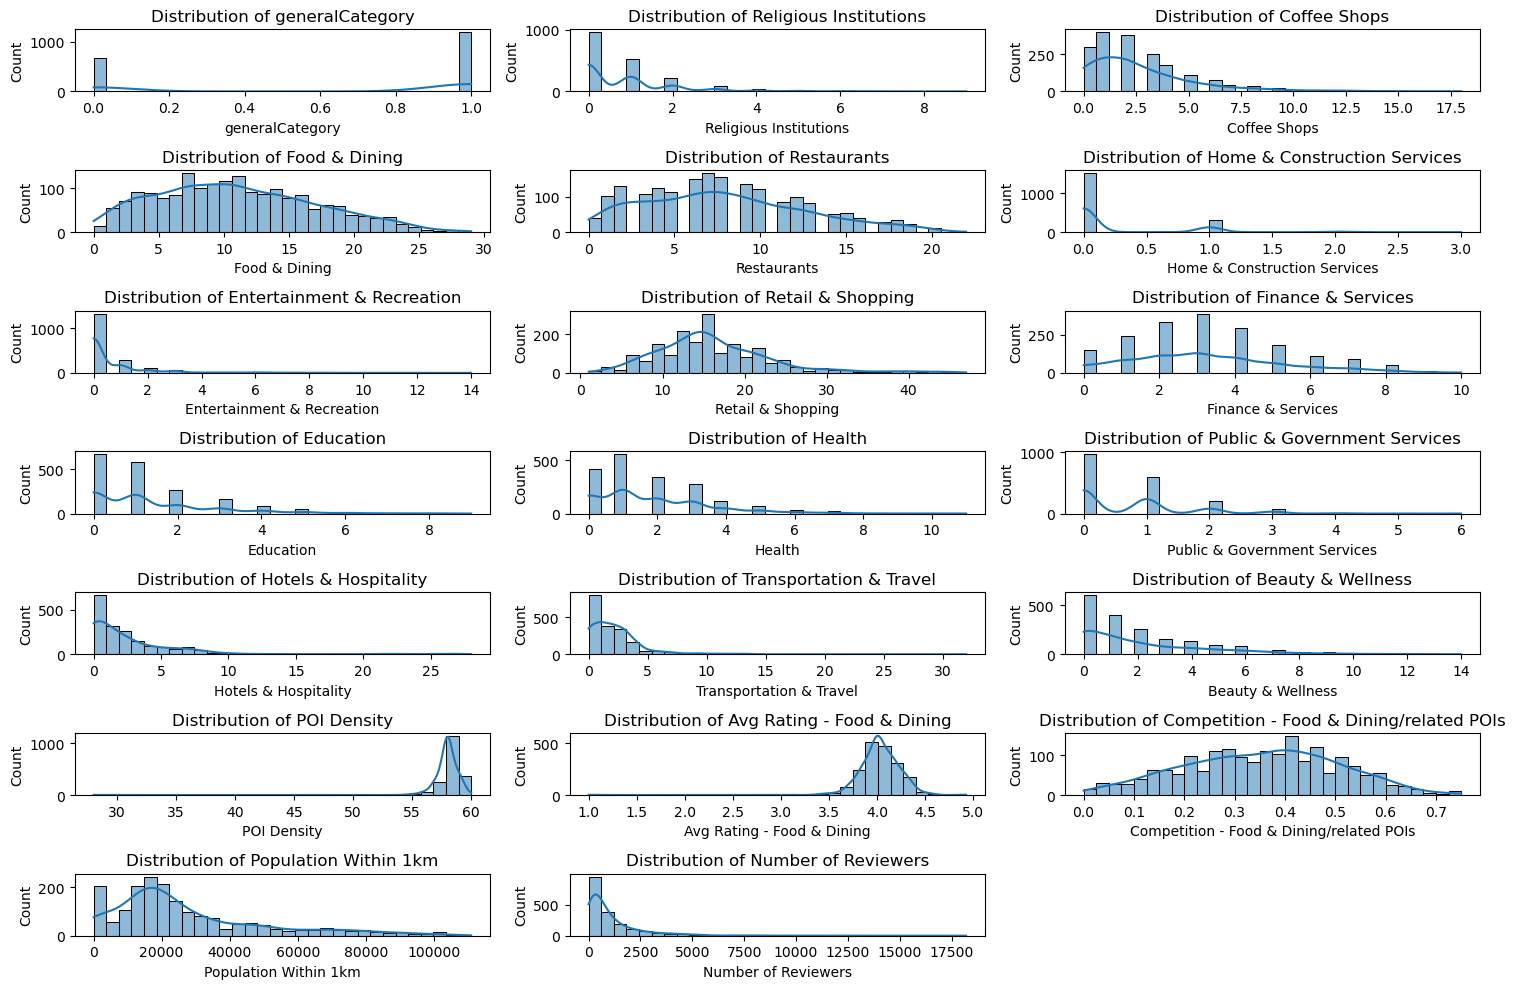

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot the distribution of all features in a DataFrame
def plot_feature_distributions(combined_df):
    num_cols = combined_df.select_dtypes(include=['number']).columns  # Select only numeric columns
    
    plt.figure(figsize=(15, 10))
    
    for i, col in enumerate(num_cols, 1):
        plt.subplot((len(num_cols) // 3) + 1, 3, i)  # Create subplots with 3 columns
        sns.histplot(combined_df[col], kde=True, bins=30)  # Histogram with KDE
        plt.title(f'Distribution of {col}')
    
    plt.tight_layout()
    plt.show()

# Call the function with your dataframe
plot_feature_distributions(combined_df)


In [122]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1861 entries, 0 to 1862
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   generalCategory                           1861 non-null   int64  
 1   Religious Institutions                    1861 non-null   int64  
 2   Coffee Shops                              1861 non-null   int64  
 3   Food & Dining                             1861 non-null   int64  
 4   Restaurants                               1861 non-null   int64  
 5   Home & Construction Services              1861 non-null   int64  
 6   Entertainment & Recreation                1861 non-null   int64  
 7   Retail & Shopping                         1861 non-null   int64  
 8   Finance & Services                        1861 non-null   int64  
 9   Education                                 1861 non-null   int64  
 10  Health                                   

### Outliers Detection

In [124]:
# Select only numeric columns, excluding "Number of Reviews"
numeric_features = combined_df.select_dtypes(include=[np.number]).columns
features = [col for col in numeric_features if col != "Number of Reviewers"]

# Function to detect outliers using IQR and count records with any outlier
def detect_outliers_iqr(df, features):
    outlier_counts = {}
    outlier_mask = np.zeros(df.shape[0], dtype=bool)  # Boolean mask to track rows with outliers

    for feature in features:
        Q1 = df[feature].quantile(0.25)  # First quartile
        Q3 = df[feature].quantile(0.75)  # Third quartile
        IQR = Q3 - Q1  # Interquartile Range
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Create a mask for outliers in this feature
        feature_outliers = (df[feature] < lower_bound) | (df[feature] > upper_bound)
        outlier_counts[feature] = feature_outliers.sum()  # Count outliers per feature
        outlier_mask |= feature_outliers  # Combine with the overall mask

    # Count records that contain at least one outlier
    num_records_with_outliers = np.sum(outlier_mask)
    
    return outlier_counts, num_records_with_outliers

# Detect outliers
outlier_results, num_outlier_records = detect_outliers_iqr(combined_df, features)

# Print the number of outliers for each feature
print("Outlier Counts Per Feature:")
for feature, count in outlier_results.items():
    print(f"{feature}: {count} outliers")

# Print the number of records that contain at least one outlier
print(f"\nNumber of records containing at least one outlier: {num_outlier_records}")


Outlier Counts Per Feature:
generalCategory: 0 outliers
Religious Institutions: 160 outliers
Coffee Shops: 80 outliers
Food & Dining: 1 outliers
Restaurants: 1 outliers
Home & Construction Services: 345 outliers
Entertainment & Recreation: 143 outliers
Retail & Shopping: 66 outliers
Finance & Services: 70 outliers
Education: 41 outliers
Health: 36 outliers
Public & Government Services: 98 outliers
Hotels & Hospitality: 138 outliers
Transportation & Travel: 91 outliers
Beauty & Wellness: 75 outliers
POI Density: 717 outliers
Avg Rating - Food & Dining: 44 outliers
Competition - Food & Dining/related POIs: 0 outliers
Population Within 1km: 148 outliers

Number of records containing at least one outlier: 1419


### Data Transformation

<class 'pandas.core.frame.DataFrame'>
Index: 1861 entries, 0 to 1862
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   generalCategory                           1861 non-null   int64  
 1   Religious Institutions                    1861 non-null   int64  
 2   Coffee Shops                              1861 non-null   int64  
 3   Food & Dining                             1861 non-null   int64  
 4   Restaurants                               1861 non-null   int64  
 5   Home & Construction Services              1861 non-null   int64  
 6   Entertainment & Recreation                1861 non-null   int64  
 7   Retail & Shopping                         1861 non-null   int64  
 8   Finance & Services                        1861 non-null   int64  
 9   Education                                 1861 non-null   int64  
 10  Health                                   

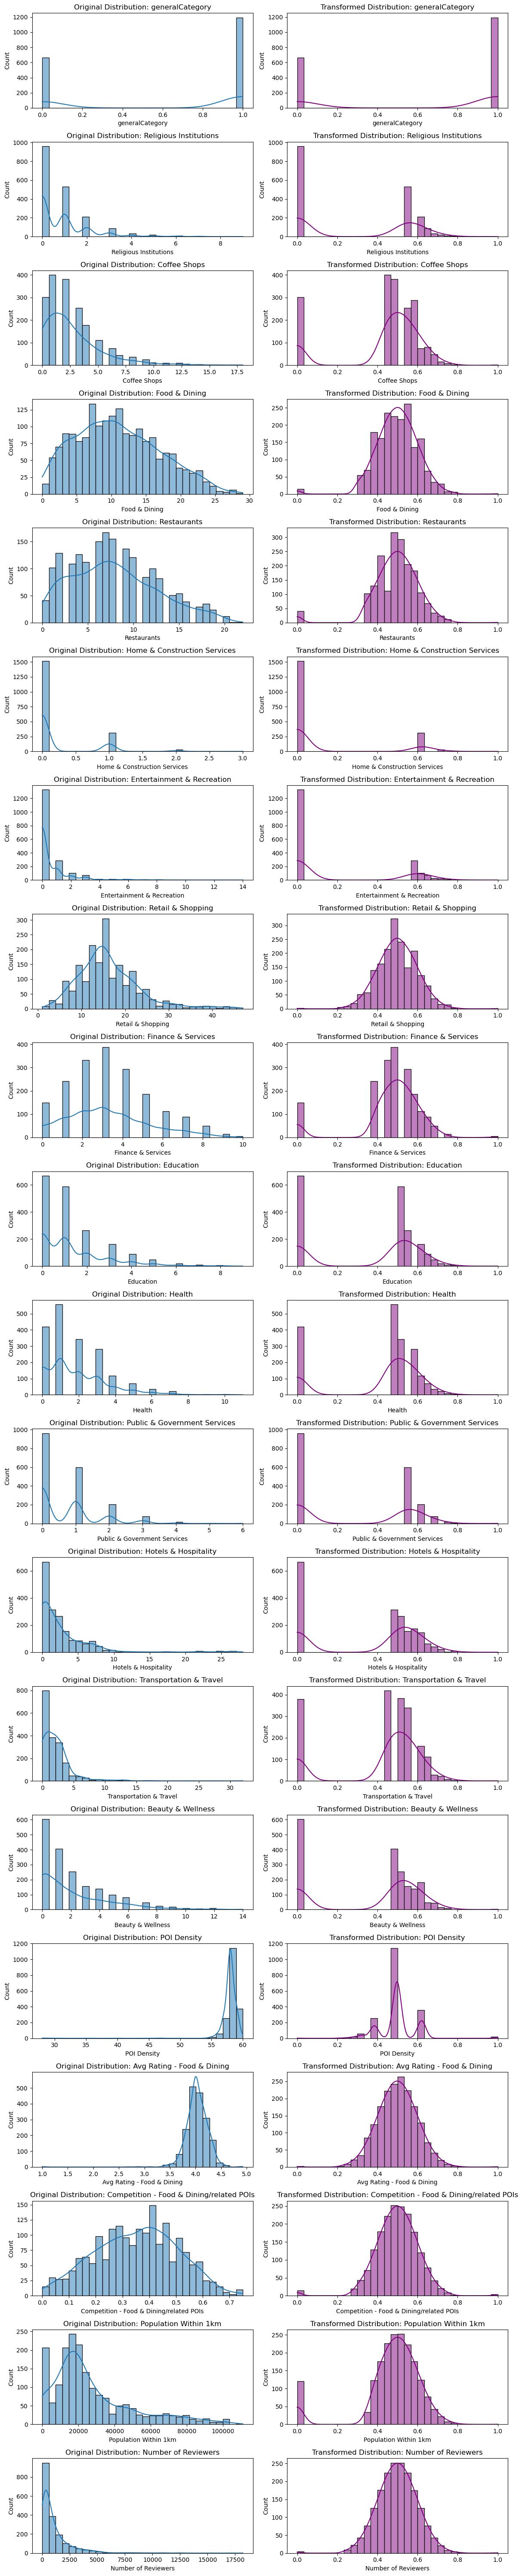

,generalCategory,Religious Institutions,Coffee Shops,Food & Dining,Restaurants,Home & Construction Services,Entertainment & Recreation,Retail & Shopping,Finance & Services,Education,Health,Public & Government Services,Hotels & Hospitality,Transportation & Travel,Beauty & Wellness,POI Density,Avg Rating - Food & Dining,Competition - Food & Dining/related POIs,Population Within 1km,Number of Reviewers
0,0.0,0.539182,0.494930,0.347214,0.341399,0.0,0.000000,0.309026,0.000000,0.000000,0.000000,0.000000,0.000000,0.741549,0.483634,0.497828,0.585784,0.459899,0.371325,0.414036
1,0.0,0.539182,0.494930,0.479085,0.510760,0.0,0.651939,0.288733,0.449377,0.000000,0.000000,0.000000,0.000000,0.558127,0.483634,0.321926,0.537875,0.629179,0.413321,0.530298
2,0.0,0.647874,0.440710,0.398937,0.410376,0.0,0.000000,0.261180,0.449377,0.563281,0.000000,0.544353,0.000000,0.558127,0.483634,0.384871,0.585784,0.635068,0.433221,0.340927
3,0.0,0.539182,0.440710,0.548968,0.597972,0.0,0.000000,0.544487,0.543817,0.000000,0.528524,0.000000,0.553557,0.454165,0.630378,0.497828,0.476234,0.524139,0.611622,0.442306
4,0.0,0.602756,0.537094,0.575987,0.597972,0.0,0.000000,0.374021,0.615129,0.000000,0.528524,0.000000,0.625130,0.507851,0.605575,0.497828,0.464461,0.599402,0.643320,0.406193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1858,1.0,0.539182,0.569718,0.575987,0.564183,0.0,0.620760,0.703840,0.000000,0.503862,0.528524,0.000000,0.000000,0.000000,0.000000,0.497828,0.453489,0.457032,0.486589,0.543550
1859,1.0,0.000000,0.537094,0.548968,0.548419,0.0,0.000000,0.582250,0.582598,0.503862,0.575823,0.544353,0.553557,0.000000,0.526889,0.497828,0.484123,0.504345,0.547346,0.477476
1860,1.0,0.000000,0.537094,0.575987,0.597972,0.0,0.577480,0.288733,0.543817,0.563281,0.469326,0.619444,0.486199,0.507851,0.581039,0.497828,0.276320,0.755007,0.368093,0.447426
1861,1.0,0.602756,0.494930,0.464719,0.468818,0.0,0.651939,0.392868,0.498311,0.503862,0.575823,0.544353,0.523890,0.604480,0.483634,0.620495,0.606017,0.501207,0.421850,0.527265


In [126]:
# Data Transformation and Scaling with QuantileTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import shapiro, probplot
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler

# Copy DataFrame
transformed_df = combined_df.copy()

# Remove outliers in 'Popularity' using IQR method
# Q1 = transformed_df['Popularity'].quantile(0.25)
# Q3 = transformed_df['Popularity'].quantile(0.75)
# IQR = Q3 - Q1
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR
# transformed_df = transformed_df[(transformed_df['Popularity'] >= lower_bound) & (transformed_df['Popularity'] <= upper_bound)]

transformed_df.info()

# Select numerical columns
num_cols = transformed_df.select_dtypes(include=['number']).columns

# Store original distributions before transformation
original_distributions = transformed_df[num_cols].copy()

# Apply QuantileTransformer (normalize distribution)
quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=42)  
# output_distribution='normal' ensures normal-like distribution
transformed_df[num_cols] = quantile_transformer.fit_transform(transformed_df[num_cols])

# Apply MinMaxScaler (scale to 0-1)
minmax_scaler = MinMaxScaler()
transformed_df[num_cols] = minmax_scaler.fit_transform(transformed_df[num_cols])

# Plot before and after transformation distributions
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(12, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    # Original distribution
    sns.histplot(original_distributions[col], kde=True, bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f'Original Distribution: {col}')
    
    # Transformed distribution
    sns.histplot(transformed_df[col], kde=True, bins=30, ax=axes[i, 1], color='purple')
    axes[i, 1].set_title(f'Transformed Distribution: {col}')

plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk test for normality on each transformed feature
normality_results = {}
for col in num_cols:
    shapiro_test_stat, shapiro_p_value = shapiro(transformed_df[col])
    normality_results[col] = {
        "Shapiro-Wilk Test Statistic": shapiro_test_stat,
        "p-value": shapiro_p_value,
        "Normality": "Yes" if shapiro_p_value > 0.05 else "No"
    }

# Convert results to DataFrame
normality_df = pd.DataFrame(normality_results).T

# Display normality test results
#print("\nShapiro-Wilk Normality Test Results:")
#print(normality_df)

# Optionally, save results to a CSV file
#normality_df.to_csv("normality_test_results.csv", index=True)

# Q-Q Plots for each transformed feature
#fig, axes = plt.subplots(nrows=len(num_cols), figsize=(6, len(num_cols) * 3))

#for i, col in enumerate(num_cols):
#    probplot(transformed_df[col], dist="norm", plot=axes[i])
#    axes[i].set_title(f"Q-Q Plot: {col}")

#plt.tight_layout()
#plt.show()
transformed_df


In [127]:
#Data Transformation and Scaling
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import shapiro, probplot
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
"""
# Copy DataFrame
transformed_df = combined_df.copy()

# Remove outliers in 'Popularity' using IQR method
#Q1 = transformed_df['Popularity'].quantile(0.25)
#Q3 = transformed_df['Popularity'].quantile(0.75)
#IQR = Q3 - Q1
#lower_bound = Q1 - 1.5 * IQR
#upper_bound = Q3 + 1.5 * IQR
#transformed_df = transformed_df[(transformed_df['Popularity'] >= lower_bound) & (transformed_df['Popularity'] <= upper_bound)]

transformed_df.info()
# Select numerical columns
num_cols = transformed_df.select_dtypes(include=['number']).columns

# Store original distributions before transformation
original_distributions = transformed_df[num_cols].copy()

# Apply PowerTransformer (normalize distribution)
power_transformer = PowerTransformer()
transformed_df[num_cols] = power_transformer.fit_transform(transformed_df[num_cols])

# Apply MinMaxScaler (scale to 0-1)
minmax_scaler = MinMaxScaler()
transformed_df[num_cols] = minmax_scaler.fit_transform(transformed_df[num_cols])

# Plot before and after transformation distributions
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(12, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    # Original distribution
    sns.histplot(original_distributions[col], kde=True, bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f'Original Distribution: {col}')
    
    # Transformed distribution
    sns.histplot(transformed_df[col], kde=True, bins=30, ax=axes[i, 1], color='purple')
    axes[i, 1].set_title(f'Transformed Distribution: {col}')

plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk test for normality on each transformed feature
normality_results = {}
for col in num_cols:
    shapiro_test_stat, shapiro_p_value = shapiro(transformed_df[col])
    normality_results[col] = {
        "Shapiro-Wilk Test Statistic": shapiro_test_stat,
        "p-value": shapiro_p_value,
        "Normality": "Yes" if shapiro_p_value > 0.05 else "No"
    }

# Convert results to DataFrame
normality_df = pd.DataFrame(normality_results).T

# Display normality test results
#print("\nShapiro-Wilk Normality Test Results:")
#print(normality_df)

# Optionally, save results to a CSV file
#normality_df.to_csv("normality_test_results.csv", index=True)

# Q-Q Plots for each transformed feature
#fig, axes = plt.subplots(nrows=len(num_cols), figsize=(6, len(num_cols) * 3))

#for i, col in enumerate(num_cols):
#    probplot(transformed_df[col], dist="norm", plot=axes[i])
#    axes[i].set_title(f"Q-Q Plot: {col}")

#plt.tight_layout()
#plt.show()
transformed_df
"""

'\n# Copy DataFrame\ntransformed_df = combined_df.copy()\n\n# Remove outliers in \'Popularity\' using IQR method\n#Q1 = transformed_df[\'Popularity\'].quantile(0.25)\n#Q3 = transformed_df[\'Popularity\'].quantile(0.75)\n#IQR = Q3 - Q1\n#lower_bound = Q1 - 1.5 * IQR\n#upper_bound = Q3 + 1.5 * IQR\n#transformed_df = transformed_df[(transformed_df[\'Popularity\'] >= lower_bound) & (transformed_df[\'Popularity\'] <= upper_bound)]\n\ntransformed_df.info()\n# Select numerical columns\nnum_cols = transformed_df.select_dtypes(include=[\'number\']).columns\n\n# Store original distributions before transformation\noriginal_distributions = transformed_df[num_cols].copy()\n\n# Apply PowerTransformer (normalize distribution)\npower_transformer = PowerTransformer()\ntransformed_df[num_cols] = power_transformer.fit_transform(transformed_df[num_cols])\n\n# Apply MinMaxScaler (scale to 0-1)\nminmax_scaler = MinMaxScaler()\ntransformed_df[num_cols] = minmax_scaler.fit_transform(transformed_df[num_cols])\

## Features Analyses 

### Pearson correlation

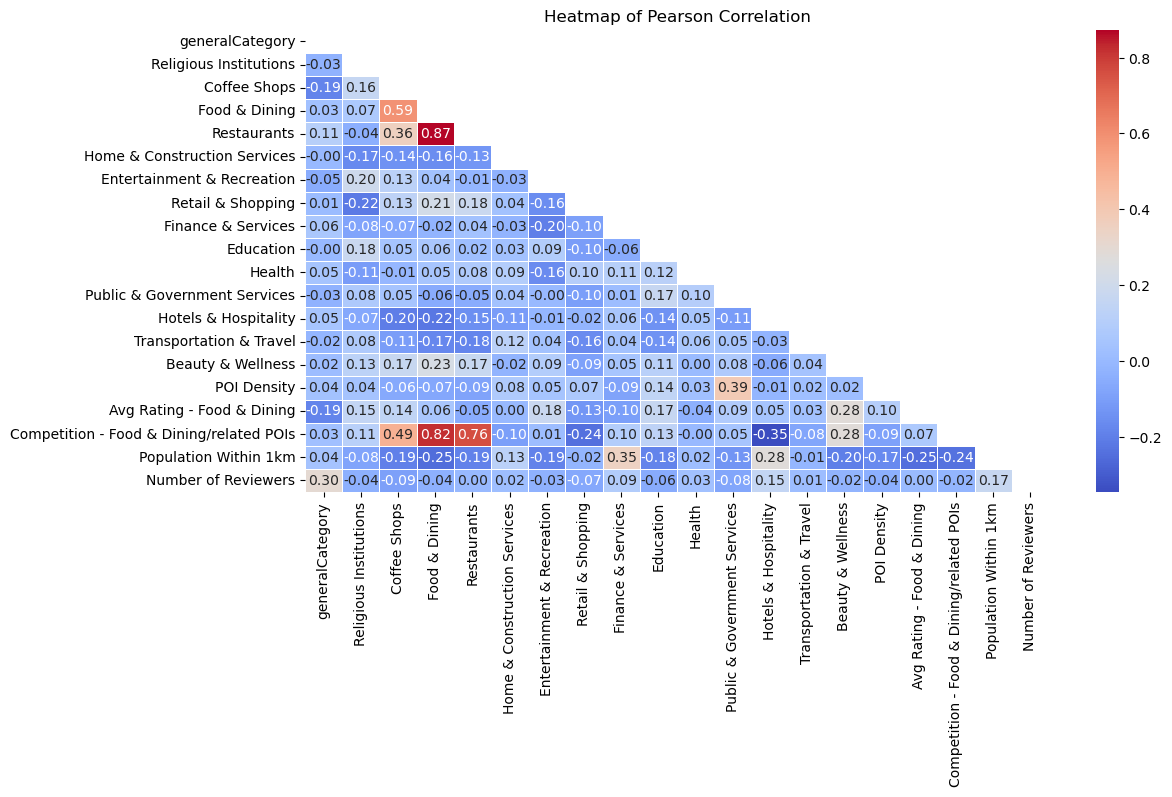

In [130]:
# Compute Pearson correlation
corr_matrix = transformed_df.corr()

# Create a mask for the upper triangular part
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Heatmap of Pearson Correlation")
plt.show()


### Scatterplots

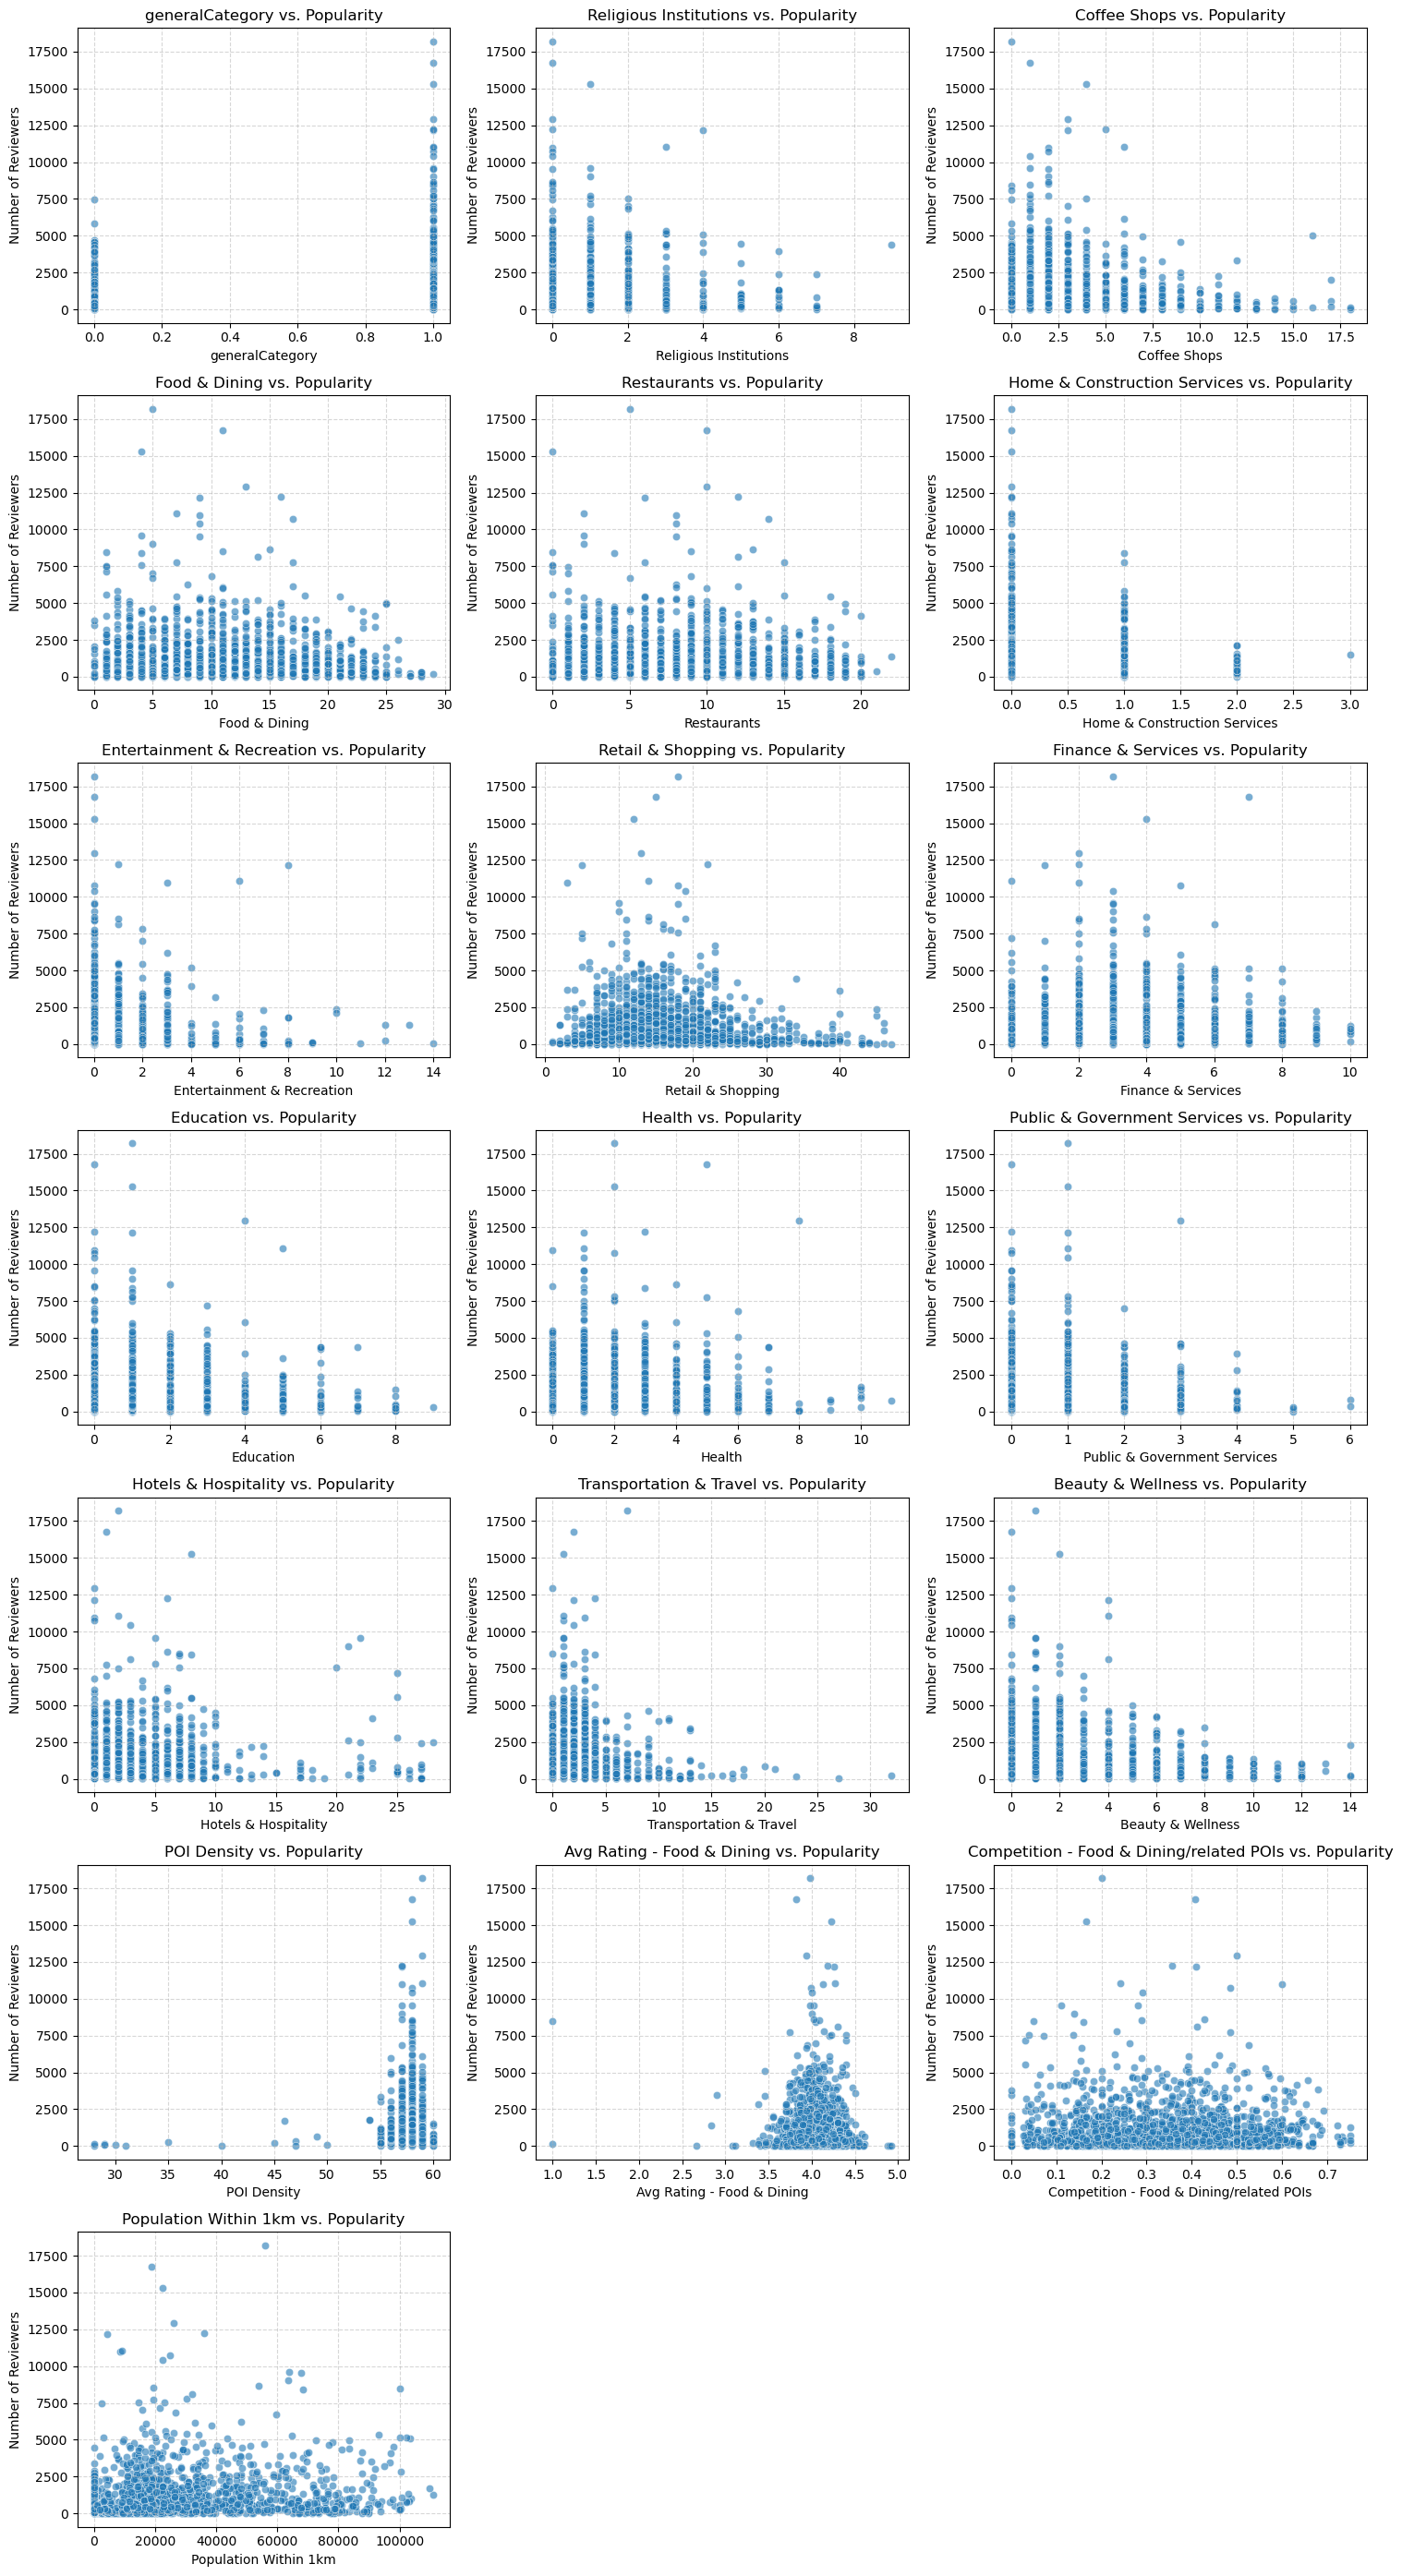

In [132]:
# Original Dataframe (WITHOUT transformation)
# Filter only numeric features (excluding target variable "Number of Reviewers")
numeric_features = combined_df.select_dtypes(include=np.number).columns
features_to_plot = [feature for feature in numeric_features if feature != "Number of Reviewers"]

# Define grid size
num_features = len(features_to_plot)
num_cols = 3  # Number of columns in the grid
num_rows = (num_features // num_cols) + (num_features % num_cols > 0)  # Compute required rows

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 4))
axes = axes.flatten()  # Flatten the 2D array of axes for easy indexing

# Loop through features and create scatter plots
for i, feature in enumerate(features_to_plot):
    sns.scatterplot(x=combined_df[feature], y=combined_df["Number of Reviewers"], alpha=0.6, ax=axes[i])
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel("Number of Reviewers", fontsize=10)
    axes[i].set_title(f"{feature} vs. Popularity", fontsize=12)
    axes[i].grid(True, linestyle="--", alpha=0.5)

# Remove empty subplots if num_features < num_cols*num_rows
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Remove unused subplots

# Adjust layout
plt.tight_layout()
plt.show()


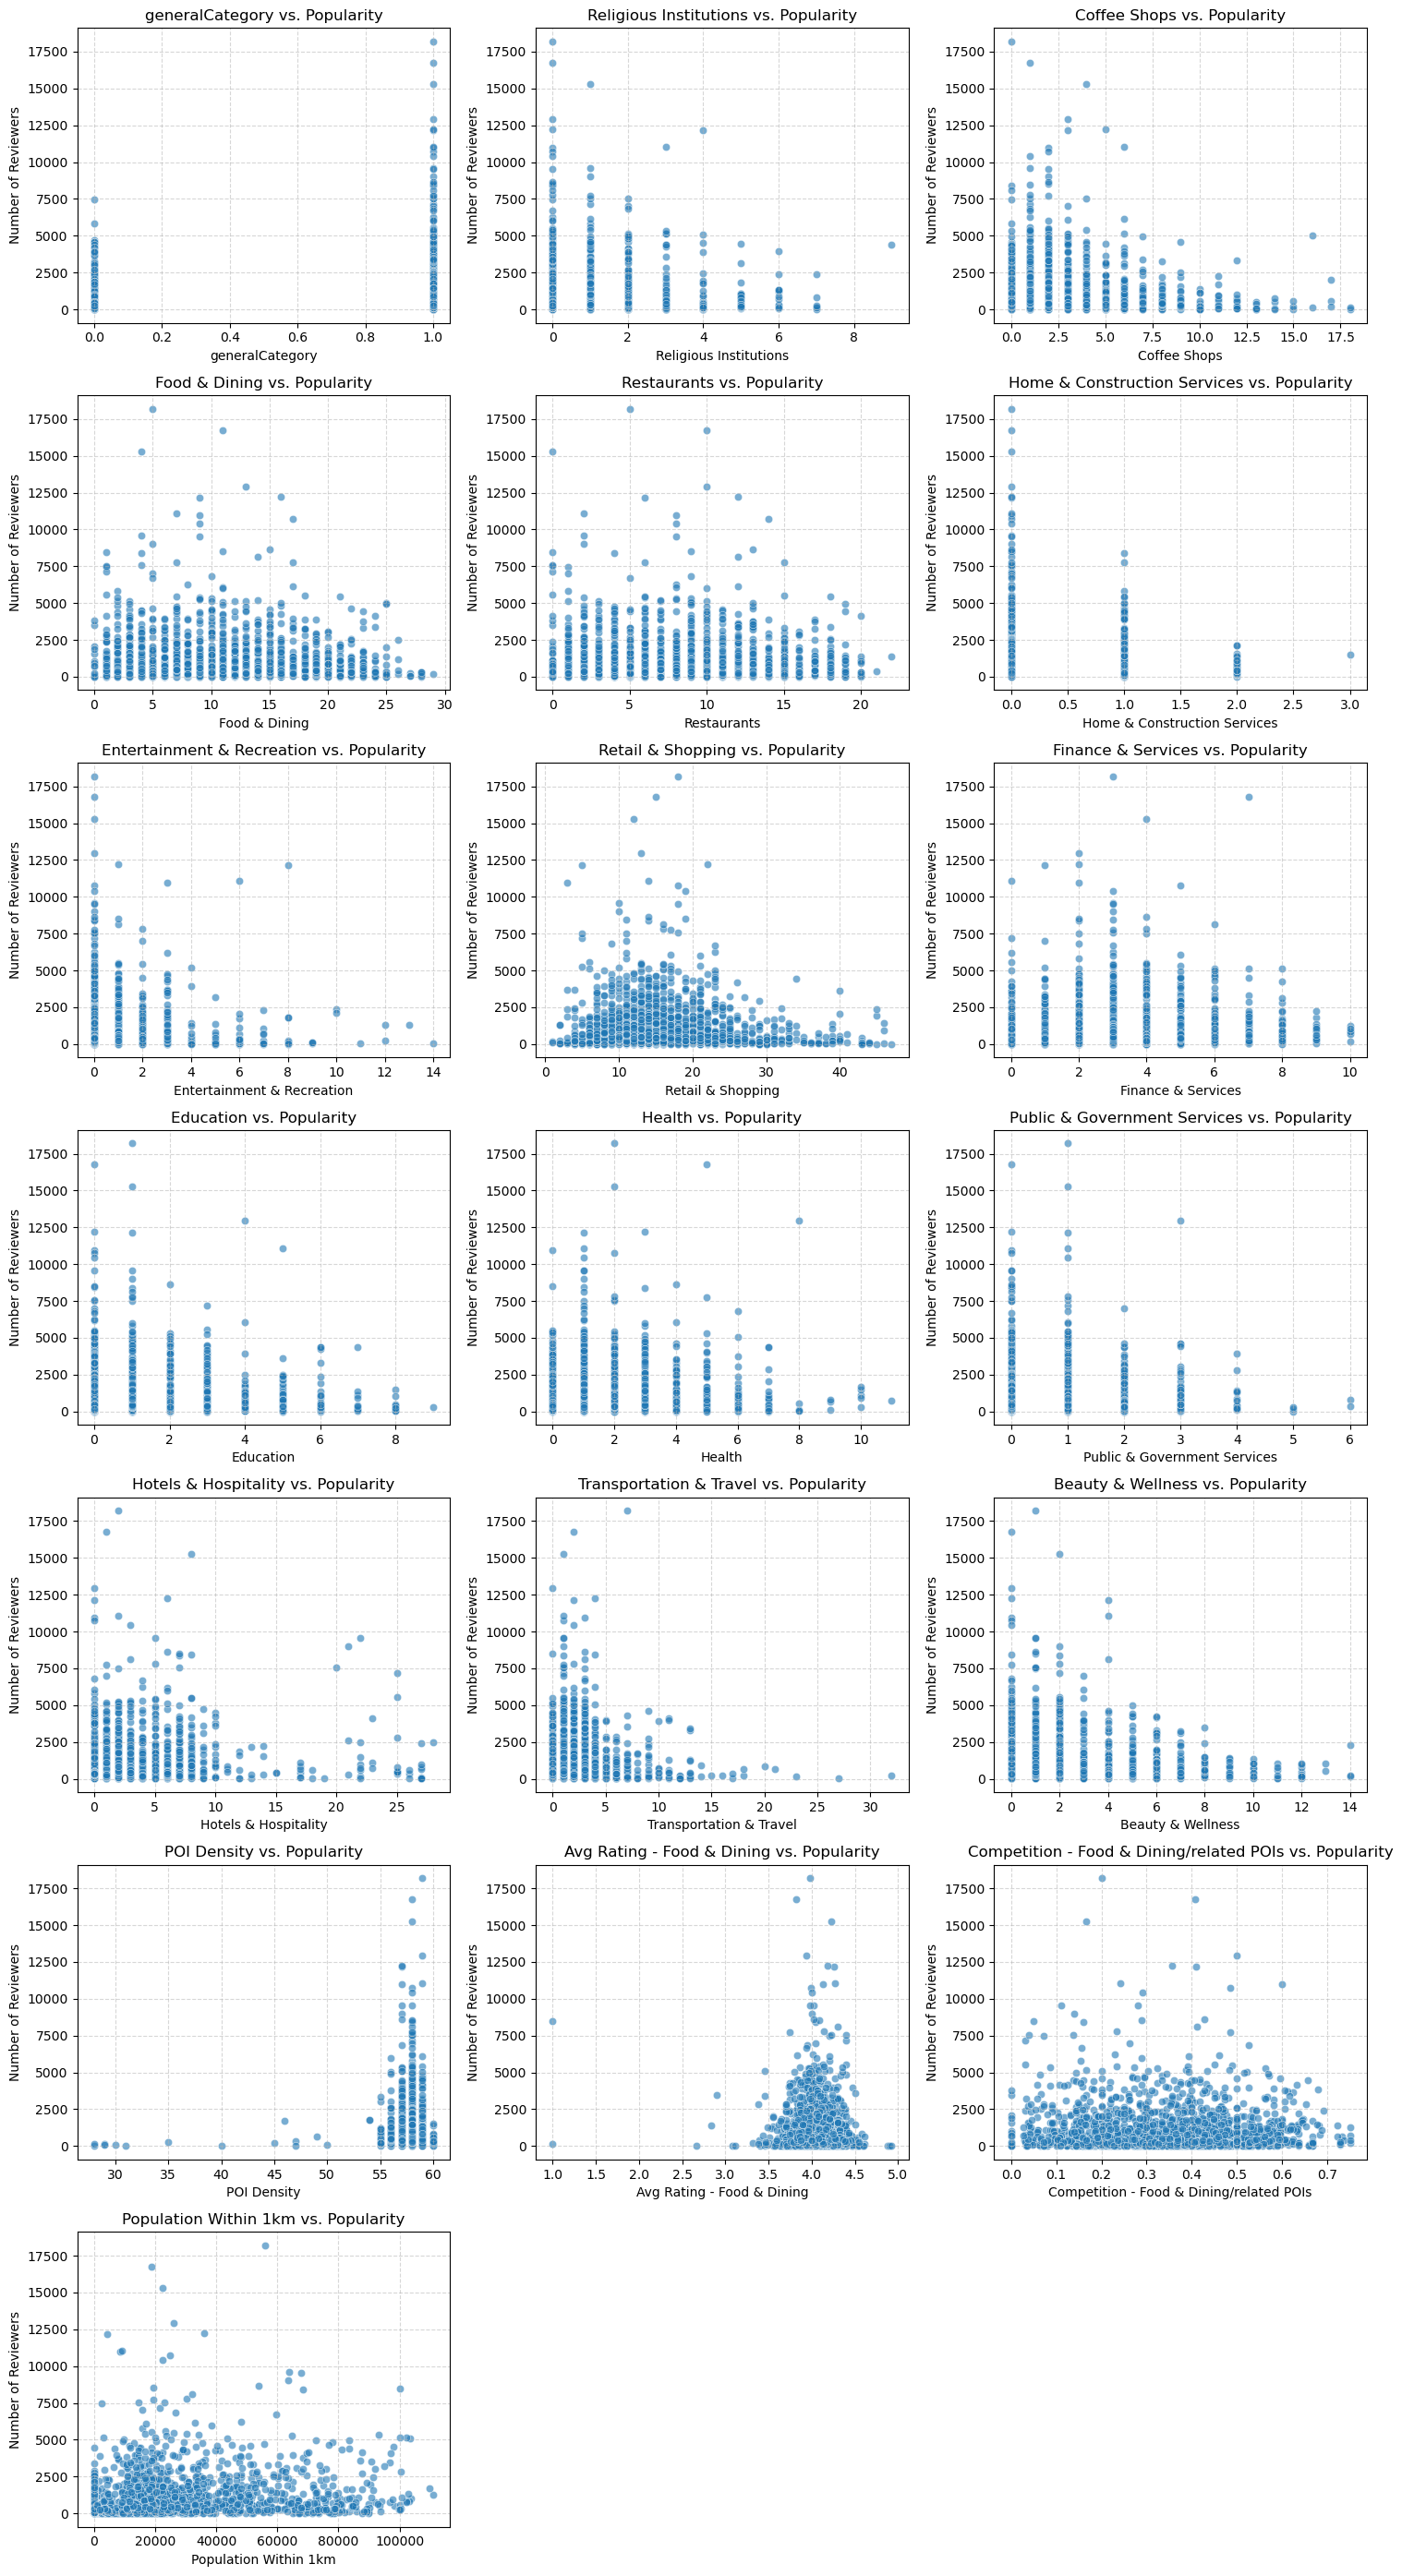

In [133]:
# transformed Dataframe 
# Filter only numeric features (excluding target variable "Number of Reviewers")
numeric_features = transformed_df.select_dtypes(include=np.number).columns
features_to_plot = [feature for feature in numeric_features if feature != "Number of Reviewers"]

# Define grid size
num_features = len(features_to_plot)
num_cols = 3  # Number of columns in the grid
num_rows = (num_features // num_cols) + (num_features % num_cols > 0)  # Compute required rows

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 4))
axes = axes.flatten()  # Flatten the 2D array of axes for easy indexing

# Loop through features and create scatter plots
for i, feature in enumerate(features_to_plot):
    sns.scatterplot(x=combined_df[feature], y=combined_df["Number of Reviewers"], alpha=0.6, ax=axes[i])
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel("Number of Reviewers", fontsize=10)
    axes[i].set_title(f"{feature} vs. Popularity", fontsize=12)
    axes[i].grid(True, linestyle="--", alpha=0.5)

# Remove empty subplots if num_features < num_cols*num_rows
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Remove unused subplots

# Adjust layout
plt.tight_layout()
plt.show()


# Experiment 1

### X and y Variables

In [136]:
# Define features (X) and target variable (y)
X = transformed_df.drop(columns=['Number of Reviewers'])
y = transformed_df['Number of Reviewers']

## Random Forest

#### Model Training and Testing

In [139]:
results = []

# Apply function and capture removed features
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
print(f"Removed highly correlated features: {removed_corr_features}")
    
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)

# Define parameter grid for tuning

param_grid = {
        "n_estimators": [50, 100, 200],  # Number of trees
        "max_depth": [None, 10, 20, 30],  # Maximum depth of trees
        "min_samples_split": [2, 5, 10],  # Minimum samples needed to split
        "min_samples_leaf": [1, 2, 4],  # Minimum samples per leaf node
        "max_features": ["sqrt", "log2"]  # Number of features to consider per split
    }
    

#scoring_metrics = ['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']

# Perform Grid Search with Cross-Validation (3-fold)
grid_search = GridSearchCV(rf_model, param_grid, scoring='r2', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Make predictions using the best model
y_pred = grid_search.best_estimator_.predict(X_test)

# Compute evaluation metrics
metrics = {
        "Best Params": grid_search.best_params_,
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MSE": mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R² Score": r2_score(y_test, y_pred),
        "MedAE": median_absolute_error(y_test, y_pred),
        "Max Error": max_error(y_test, y_pred),
        "MAD": median_abs_deviation(y_test - y_pred)
}
results.append(metrics)

# Display results in a table
print("\nFinal Metrics Comparison Table:")
#print(tabulate(results, headers="keys", tablefmt="fancy_grid", floatfmt=".6f"))


# Compute Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
mad = median_abs_deviation(y_test - y_pred)  # Mean Absolute Deviation

print("Best Grid Parameters", grid_search.best_params_) 
# Print Results in Table Format
print(f"{'Metric':<15} │ {'Value':>10}")
print("-" * 35)
print(f"{'RMSE':<15} │ {rmse:>10.6f}")
print(f"{'MSE':<15} │ {mse:>10.6f}")
print(f"{'MAE':<15} │ {mae:>10.6f}")
print(f"{'R²':<15} │ {r2:>10.6f}")
print(f"{'MedAE':<15} │ {medae:>10.6f}")
print(f"{'Max Error':<15} │ {max_err:>10.6f}")
print(f"{'MAD':<15} │ {mad:>10.6f}")

Removed highly correlated features: []
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Final Metrics Comparison Table:
Best Grid Parameters {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Metric          │      Value
-----------------------------------
RMSE            │   0.090340
MSE             │   0.008161
MAE             │   0.071482
R²              │   0.162465
MedAE           │   0.060800
Max Error       │   0.454714
MAD             │   0.060227


#### Features Importance

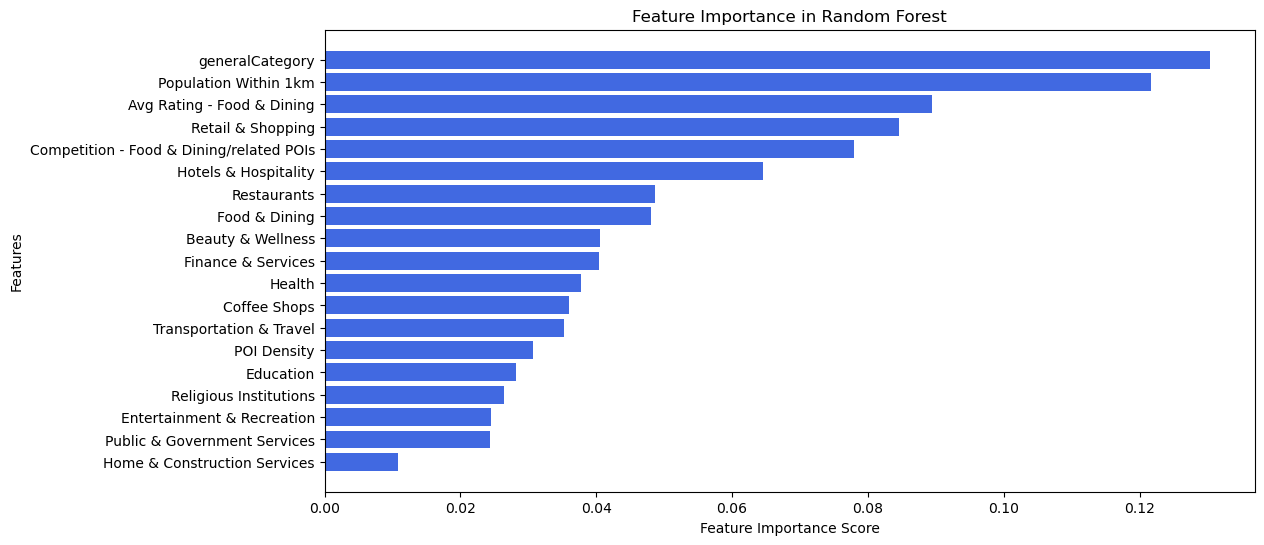


Feature Importance Scores:
                                     Feature  Importance
0                            generalCategory    0.130425
18                     Population Within 1km    0.121682
16                Avg Rating - Food & Dining    0.089396
7                          Retail & Shopping    0.084613
17  Competition - Food & Dining/related POIs    0.077954
12                      Hotels & Hospitality    0.064483
4                                Restaurants    0.048591
3                              Food & Dining    0.048039
14                         Beauty & Wellness    0.040512
8                         Finance & Services    0.040443
10                                    Health    0.037758
2                               Coffee Shops    0.036040
13                   Transportation & Travel    0.035198
15                               POI Density    0.030642
9                                  Education    0.028111
1                     Religious Institutions    0.026410
6  

In [141]:
# Compute feature importance from the best estimator
best_rf_model = grid_search.best_estimator_
feature_importance = best_rf_model.feature_importances_

# Create DataFrame for feature importance
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='royalblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Random Forest")
plt.gca().invert_yaxis()  # Highest importance on top
plt.show()

# Display feature importance values
print("\nFeature Importance Scores:")
print(feature_importance_df)

### XGBoost

In [143]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
from scipy.stats import median_abs_deviation

results = []

# Apply function and capture removed features
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
print(f"Removed highly correlated features: {removed_corr_features}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize XGBoost Regressor
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Define parameter grid for tuning
param_grid = {
    "n_estimators": [50, 100, 200],  # Number of trees
    "max_depth": [3, 5, 10],  # Maximum depth of trees
    "learning_rate": [0.01, 0.1, 0.2],  # Learning rate
    "subsample": [0.8, 1.0],  # Subsample ratio
    "colsample_bytree": [0.8, 1.0]  # Feature fraction per tree
}

# Perform Grid Search with Cross-Validation (3-fold)
grid_search = GridSearchCV(xgb_model, param_grid, scoring="r2", cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Make predictions using the best model
y_pred = grid_search.best_estimator_.predict(X_test)

# Compute evaluation metrics
metrics = {
    "Best Params": grid_search.best_params_,
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    "MSE": mean_squared_error(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "R² Score": r2_score(y_test, y_pred),
    "MedAE": median_absolute_error(y_test, y_pred),
    "Max Error": max_error(y_test, y_pred),
    "MAD": median_abs_deviation(y_test - y_pred)
}
results.append(metrics)

# Compute Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
mad = median_abs_deviation(y_test - y_pred)  # Mean Absolute Deviation

print("Best Grid Parameters", grid_search.best_params_)
# Print Results in Table Format
print(f"{'Metric':<15} │ {'Value':>10}")
print("-" * 35)
print(f"{'RMSE':<15} │ {rmse:>10.6f}")
print(f"{'MSE':<15} │ {mse:>10.6f}")
print(f"{'MAE':<15} │ {mae:>10.6f}")
print(f"{'R²':<15} │ {r2:>10.6f}")
print(f"{'MedAE':<15} │ {medae:>10.6f}")
print(f"{'Max Error':<15} │ {max_err:>10.6f}")
print(f"{'MAD':<15} │ {mad:>10.6f}")


Removed highly correlated features: []
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Grid Parameters {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Metric          │      Value
-----------------------------------
RMSE            │   0.091163
MSE             │   0.008311
MAE             │   0.072720
R²              │   0.147128
MedAE           │   0.059615
Max Error       │   0.459310
MAD             │   0.059603


### SVR

In [145]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from scipy.stats import boxcox

# Apply function and capture removed features for correlation
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
print(f"Removed highly correlated features: {removed_corr_features}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check for NaNs, infinite values, or constant features
def check_nan_inf(X, y):
    if X.isnull().sum().sum() > 0 or np.isnan(y).sum() > 0:
        raise ValueError("NaNs detected in the data. Please handle missing values.")
    if np.isinf(X).sum().sum() > 0 or np.isinf(y).sum() > 0:
        raise ValueError("Infinite values detected in the data. Check transformations and scaling.")
    if (X.var() == 0).any():
        raise ValueError("Constant features detected. Consider dropping them.")

# Check for constant features in X_train
constant_features = [col for col in X_train.columns if X_train[col].nunique() == 1]

# Drop constant features
X_train = X_train.drop(columns=constant_features)
X_test = X_test.drop(columns=constant_features)

# Print out constant features that were removed
print(f"Removed constant features: {constant_features}")


# Check for NaNs or infinite values in the data
check_nan_inf(X_train, y_train)

# Set up the pipeline
model = Pipeline([
    ('svr', SVR())  # Apply SVR without additional transformation on the target
])

# Define parameter grid for tuning SVR
param_grid = {
    'svr__C': [0.01, 0.1, 1, 10],
    'svr__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 2],
    'svr__epsilon': [0.001, 0.01, 0.05, 0.1],
    'svr__kernel': ['rbf', 'sigmoid']
}

# GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(model, param_grid, scoring="r2", cv=5, n_jobs=-1, verbose=2)

# Fit the model with training data
grid_search.fit(X_train, y_train)

# Print best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best score (MSE): ", -grid_search.best_score_)

# Test set predictions using the best estimator
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Predictions on test data completed with the best model.")

# Calculate and print evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
mad = np.mean(np.abs(y_test - np.mean(y_test)))

# Print results in table format
print(f"{'Metric':<15} │ {'Value':>10}")
print("-" * 35)
print(f"{'RMSE':<15} │ {rmse:>10.4f}")
print(f"{'MSE':<15} │ {mse:>10.4f}")
print(f"{'MAE':<15} │ {mae:>10.4f}")
print(f"{'R²':<15} │ {r2:>10.4f}")
print(f"{'MedAE':<15} │ {medae:>10.4f}")
print(f"{'Max Error':<15} │ {max_err:>10.4f}")
print(f"{'MAD':<15} │ {mad:>10.4f}")

print("Model evaluation completed!")

Removed highly correlated features: []
Removed constant features: []
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best parameters found:  {'svr__C': 1, 'svr__epsilon': 0.05, 'svr__gamma': 0.1, 'svr__kernel': 'rbf'}
Best score (MSE):  -0.1699351689749003
Predictions on test data completed with the best model.
Metric          │      Value
-----------------------------------
RMSE            │     0.0944
MSE             │     0.0089
MAE             │     0.0731
R²              │     0.0853
MedAE           │     0.0616
Max Error       │     0.4901
MAD             │     0.0778
Model evaluation completed!


### LSTM

In [147]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
from scipy.stats import median_abs_deviation

# Define features (X) and target variable (y)
X = transformed_df.drop(columns=['Number of Reviewers']).values
y = transformed_df['Number of Reviewers'].values

# Reshape for LSTM (samples, timesteps, features)
X = X.reshape((X.shape[0], 1, X.shape[1]))

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Convert to PyTorch tensors
X_train, X_test = torch.tensor(X_train, dtype=torch.float32), torch.tensor(X_test, dtype=torch.float32)
y_train, y_test = torch.tensor(y_train, dtype=torch.float32).view(-1, 1), torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Define LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])

# Initialize model
input_size = X_train.shape[2]
hidden_size = 50
num_layers = 2
output_size = 1
model = LSTMModel(input_size, hidden_size, num_layers, output_size)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train model
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.6f}')

# Make predictions
model.eval()
y_pred = model(X_test).detach().numpy()
y_test = y_test.numpy()

# Compute evaluation metrics
metrics = {
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    "MSE": mean_squared_error(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "R² Score": r2_score(y_test, y_pred),
    "MedAE": median_absolute_error(y_test, y_pred),
    "Max Error": max_error(y_test, y_pred),
    "MAD": median_abs_deviation(y_test - y_pred)
}

# Display results
print("\nFinal Metrics Comparison Table:")
print(f"{'Metric':<15} │ {'Value':>10}")
print("-" * 35)
for key, value in metrics.items():
    print(f"{key:<15} │ {value:>10.6f}")


Epoch 0, Loss: 0.300960
Epoch 10, Loss: 0.218686
Epoch 20, Loss: 0.125888
Epoch 30, Loss: 0.032567
Epoch 40, Loss: 0.016320

Final Metrics Comparison Table:
Metric          │      Value
-----------------------------------
RMSE            │   0.126953
MSE             │   0.016117
MAE             │   0.103518
R² Score        │  -0.904536
MedAE           │   0.092018
Max Error       │   0.338334


TypeError: unsupported format string passed to numpy.ndarray.__format__